# ============================================================
#  Sales Data Cleaning Script
#  Input : Sales_Data.csv  (semicolon-delimited)

# ── 1. IMPORT LIBRARIES ─────────────────────────────────────

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from matplotlib.ticker import FuncFormatter

# # ── 2. LOAD DATA 

In [2]:
df = pd.read_csv("Sales_Data.csv", sep=";")

In [5]:
print("=" * 55)
print("BEFORE CLEANING")
print("=" * 55)

BEFORE CLEANING


In [7]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 185,950 rows × 11 columns


In [8]:
print(f"Duplicate rows   : {df.duplicated().sum():,}")

Duplicate rows   : 0


In [9]:
print(f"Missing values   : {df.isnull().sum().sum():,}")

Missing values   : 0


In [10]:
print(f"Columns          : {df.columns.tolist()}")

Columns          : ['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour']


# # ── 3. DROP JUNK INDEX COLUMN ───────────────────────────────
'Unnamed: 0' is a leftover row-number artifact from a
 previous export — not meaningful data

In [11]:
df.drop(columns=["Unnamed: 0"], inplace=True)

# # ── 4. STANDARDIZE COLUMN NAMES ─────────────────────────────

In [12]:
# Remove spaces, lowercase everything → enables dot-notation access.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# # ── 5. STRIP LEADING / TRAILING SPACES FROM CITY ────────────

In [13]:
df["city"] = df["city"].str.strip()

# # ── 6. PARSE ORDER DATE INTO DATETIME ───────────────────────

In [14]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

# # ── 7. DROP REDUNDANT MONTH & HOUR COLUMNS ──────────────────

In [15]:
df.drop(columns=["month", "hour"], inplace=True)
df["month"] = df["order_date"].dt.month
df["hour"]  = df["order_date"].dt.hour

# ── 8. FIX SALES FLOATING-POINT ERRORS ──────────────────────

In [16]:
df["sales"] = (df["price_each"] * df["quantity_ordered"]).round(2)

 # ── 9. HANDLE DUPLICATE ORDER IDs ───────────────────────────

In [17]:
assert (df["quantity_ordered"] > 0).all(), "Found quantity <= 0"
assert (df["price_each"]       > 0).all(), "Found price <= 0"
assert (df["sales"]            > 0).all(), "Found sales <= 0"

# ── 11. REORDER COLUMNS ─────────────────────────────────────

In [18]:
df = df[[
    "order_id",
    "order_date",
    "month",
    "hour",
    "product",
    "quantity_ordered",
    "price_each",
    "sales",
    "city",
    "purchase_address",
]]

# ── 12. EXPORT CLEANED DATA ─────────────────────────────────

In [19]:
output_path = "Sales_Data_Cleaned.csv"
df.to_csv(output_path, index=False)

In [ ]:
print("=" * 55)
print("AFTER CLEANING")
print("=" * 55)
print(f"Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Duplicate rows   : {df.duplicated().sum():,}")
print(f"Missing values   : {df.isnull().sum().sum():,}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Date range       : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Cities           : {sorted(df['city'].unique())}")
print(f"Saved to         : {output_path}")
print()
print("Sample (first 3 rows):")
print(df.head(3).to_string(index=False))

# KPI Calculations

In [24]:
# Total Sales

total_sales = df['sales'].sum()

# Total Items Sold

total_items = df['quantity_ordered'].sum()

# Average Order Value

average_order_value = total_sales / df['order_id'].nunique()

# Best Sales Month

monthly_sales = df.groupby('month')['sales'].sum()

best_month = monthly_sales.idxmax()

best_month_sales = monthly_sales.max()

# Top Performing City

city_sales = df.groupby('city')['sales'].sum()

top_city = city_sales.idxmax()

# Top Product

product_sales = df.groupby('product')['sales'].sum()

top_product = product_sales.idxmax()

print('Total Sales:', total_sales)
print('Total Items Sold:', total_items)
print('Average Order Value:', average_order_value)
print('Best Month:', best_month)
print('Top City:', top_city)
print('Top Product:', top_product)

Total Sales: 34492035.97
Total Items Sold: 209079
Average Order Value: 193.30091836334392
Best Month: 12
Top City: San Francisco
Top Product: Macbook Pro Laptop


# Monthly Sales Trend Chart

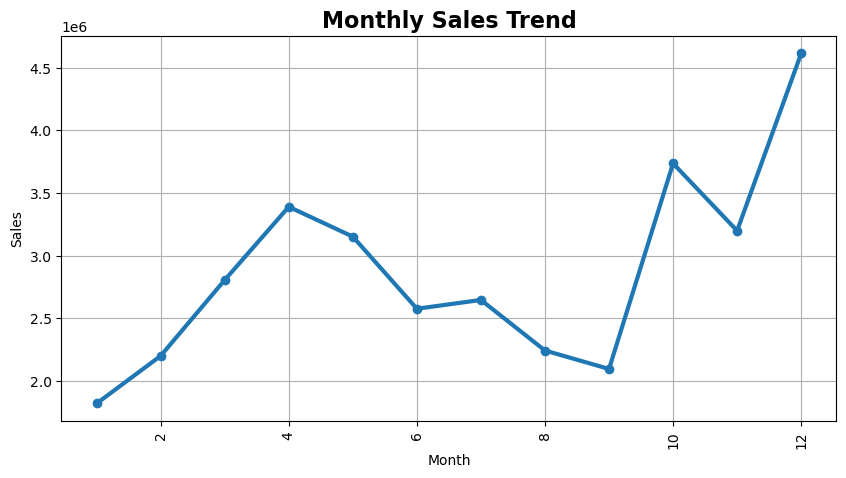

In [27]:
monthly_sales = df.groupby('month')['sales'].sum().reset_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['month'],
    monthly_sales['sales'],
    marker='o',
    linewidth=3
)

plt.title('Monthly Sales Trend', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

# Sales Contribution by City (Pie Chart)

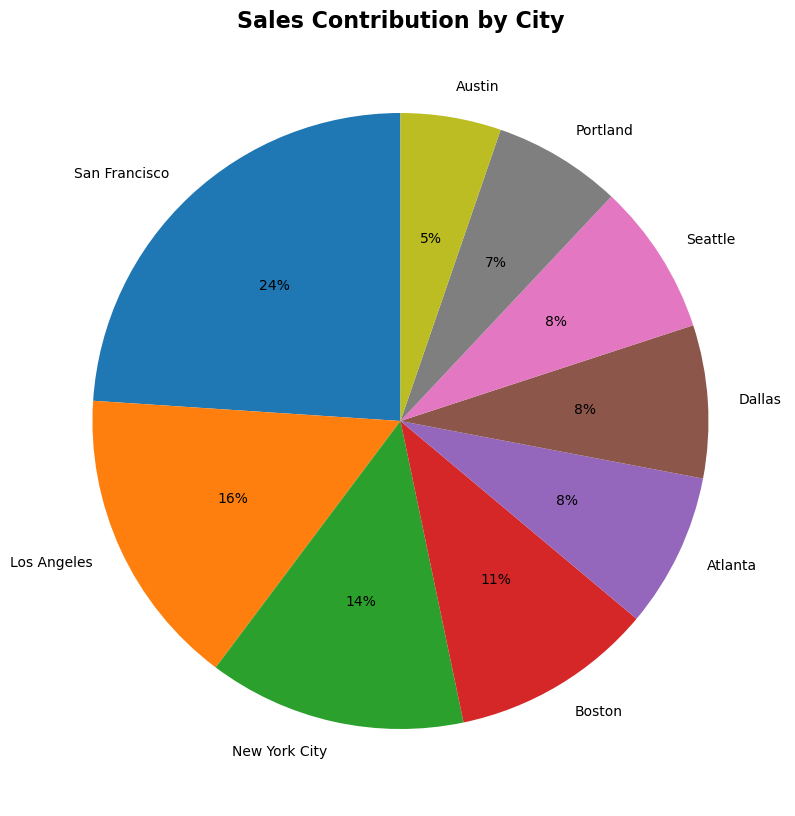

In [29]:
city_sales = df.groupby('city')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,10))

plt.pie(
    city_sales,
    labels=city_sales.index,
    autopct='%1.0f%%',
    startangle=90
)

plt.title('Sales Contribution by City', fontsize=16, weight='bold')

plt.show()

# Sales by City (Horizontal Bar)

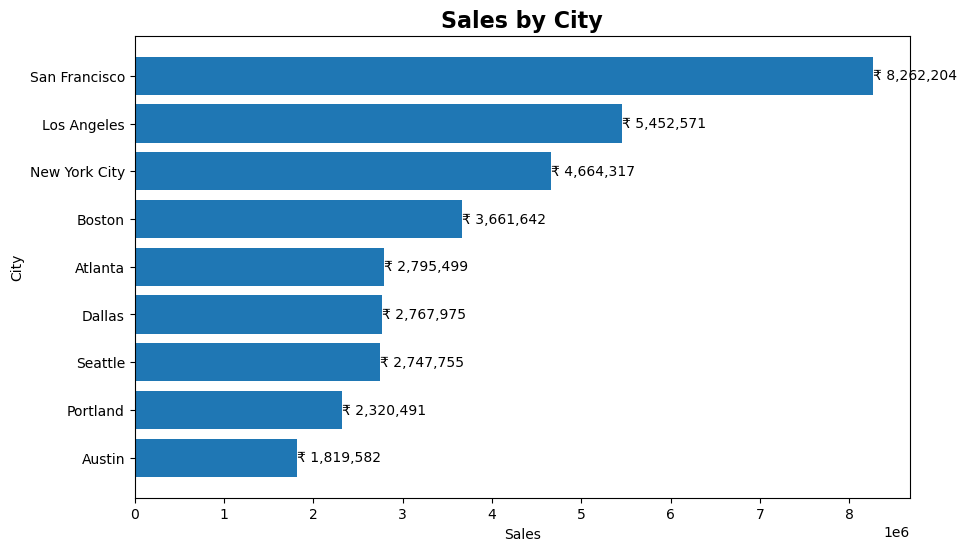

In [30]:
city_sales = df.groupby('city')['sales'].sum().sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(city_sales.index, city_sales.values)

plt.title('Sales by City', fontsize=16, weight='bold')
plt.xlabel('Sales')
plt.ylabel('City')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'₹ {width:,.0f}',
        va='center'
    )

plt.show()

# Total Items Sold by Month

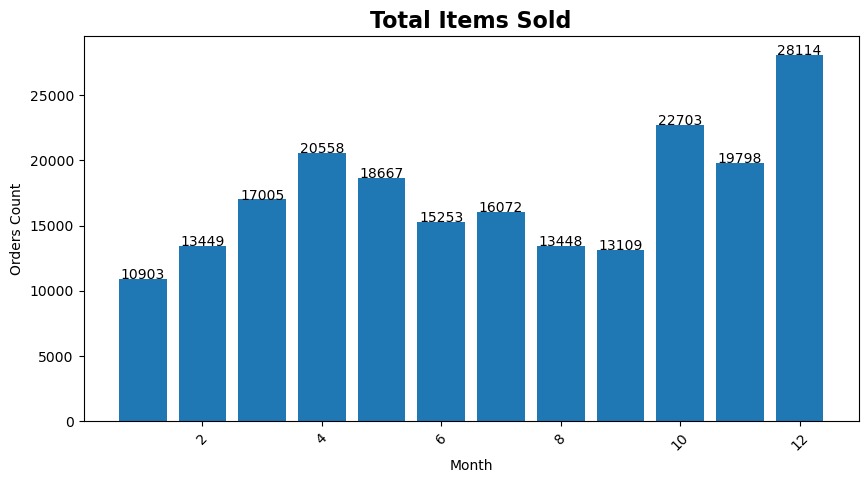

In [32]:
monthly_items = df.groupby('month')['quantity_ordered'].sum().reset_index()

plt.figure(figsize=(10,5))

bars = plt.bar(
    monthly_items['month'],
    monthly_items['quantity_ordered']
)

plt.title('Total Items Sold', fontsize=16, weight='bold')
plt.xlabel('Month')
plt.ylabel('Orders Count')

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center'
    )

plt.show()

# Top 5 Products Chart

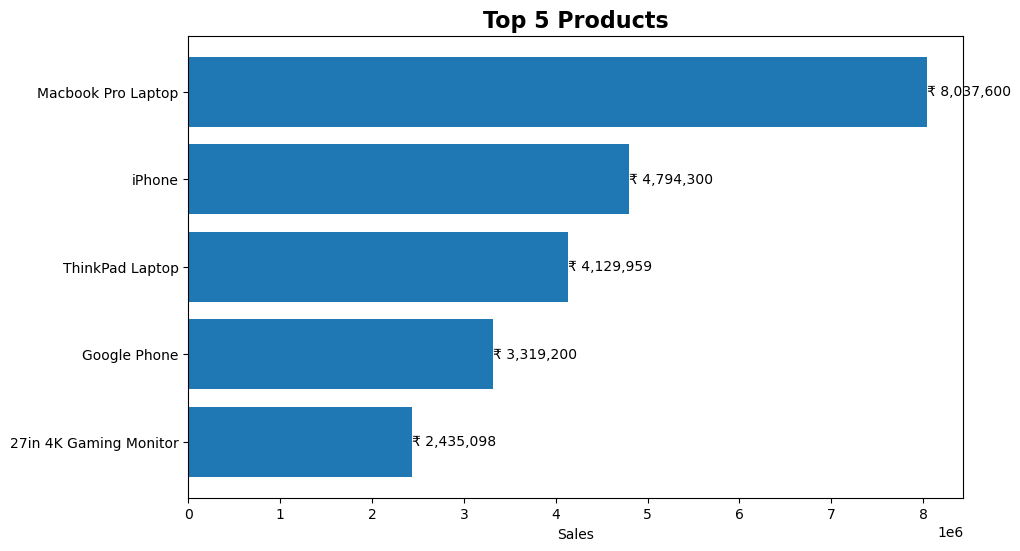

In [33]:
product_sales = (
    df.groupby('product')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    product_sales.index[::-1],
    product_sales.values[::-1]
)

plt.title('Top 5 Products', fontsize=16, weight='bold')
plt.xlabel('Sales')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'₹ {width:,.0f}',
        va='center'
    )

plt.show()

In [34]:
fig = plt.figure(figsize=(22,12))

# Background color
fig.patch.set_facecolor('#c7d3e0')

# Main title
plt.suptitle(
    'Sales Performance Dashboard - 2019',
    fontsize=30,
    weight='bold'
)

Text(0.5, 0.98, 'Sales Performance Dashboard - 2019')

<Figure size 2200x1200 with 0 Axes>

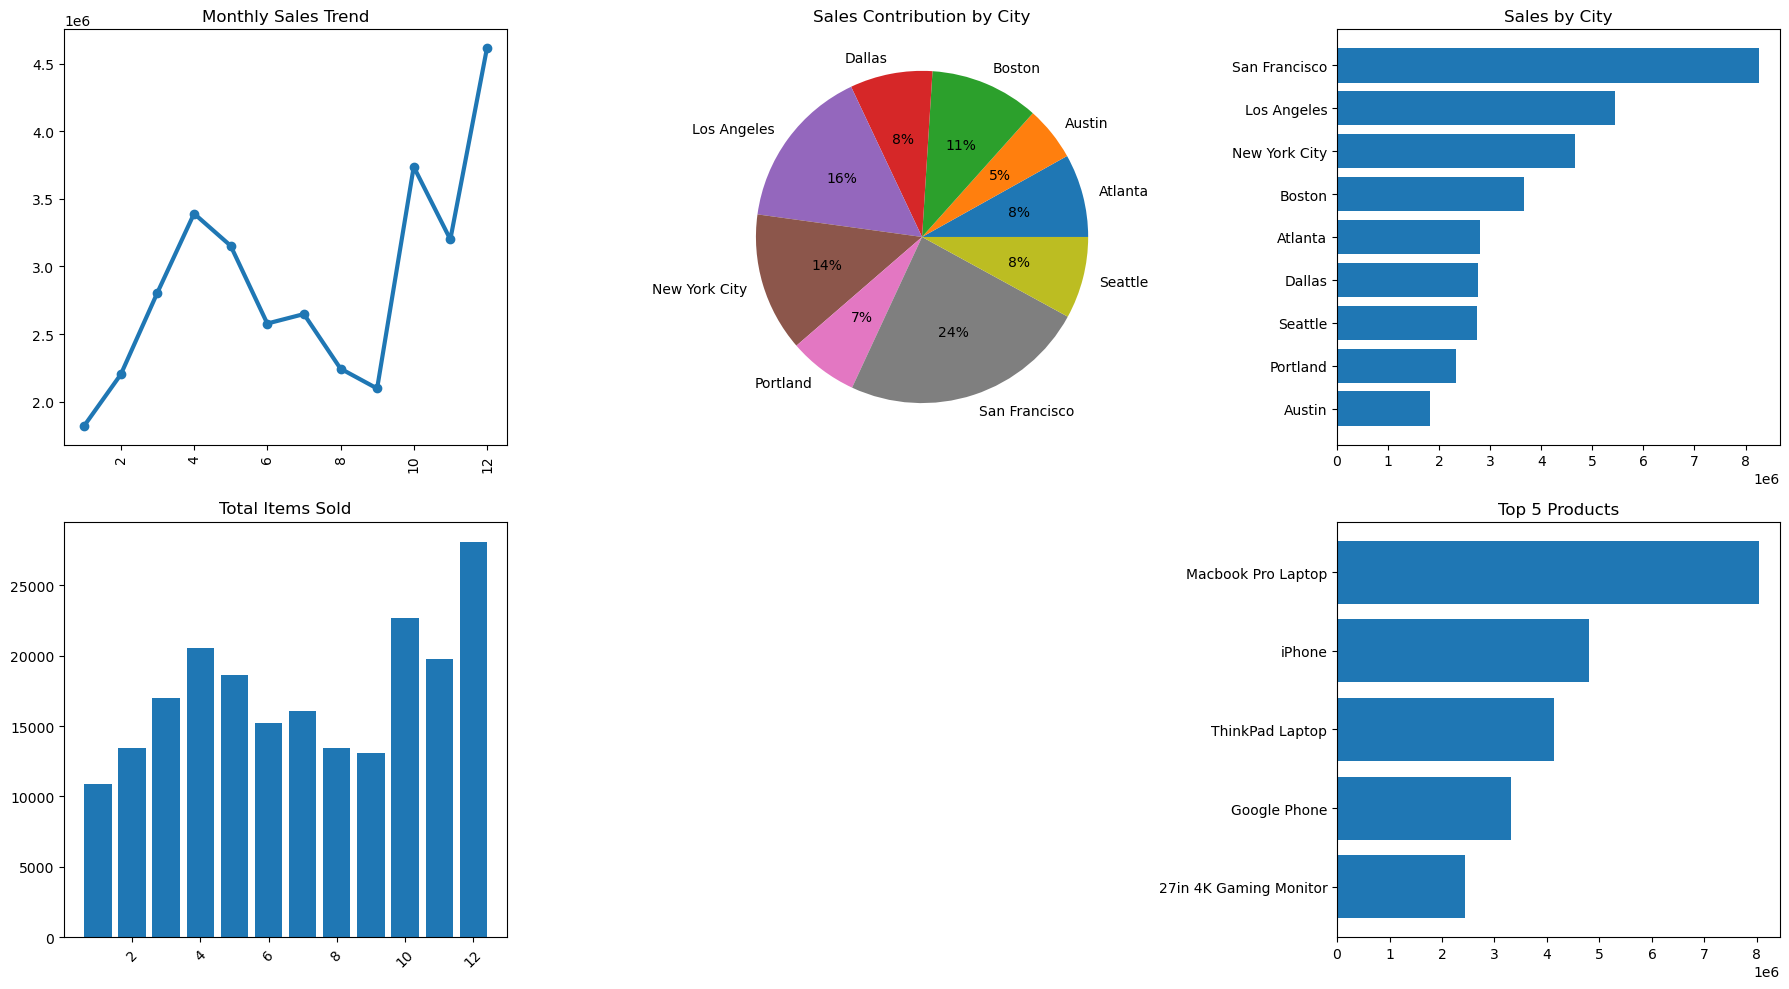

In [36]:
import matplotlib.pyplot as plt

# Create subplot layout
fig, axs = plt.subplots(2, 3, figsize=(18, 10))


# Monthly Sales Trend
monthly_sales = df.groupby('month')['sales'].sum()

axs[0,0].plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=3,
    marker='o'
)

axs[0,0].set_title('Monthly Sales Trend')
axs[0,0].tick_params(axis='x', rotation=90)


# Pie Chart - Sales Contribution by City
city_sales = df.groupby('city')['sales'].sum()

axs[0,1].pie(
    city_sales.values,
    labels=city_sales.index,
    autopct='%1.0f%%'
)

axs[0,1].set_title('Sales Contribution by City')


# Sales by City
city_sales_sorted = city_sales.sort_values()

axs[0,2].barh(
    city_sales_sorted.index,
    city_sales_sorted.values
)

axs[0,2].set_title('Sales by City')


# Total Items Sold
monthly_items = df.groupby('month')['quantity_ordered'].sum()

axs[1,0].bar(
    monthly_items.index,
    monthly_items.values
)

axs[1,0].set_title('Total Items Sold')
axs[1,0].tick_params(axis='x', rotation=45)


# Empty middle chart
axs[1,1].axis('off')


# Top 5 Products
product_sales = (
    df.groupby('product')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

axs[1,2].barh(
    product_sales.index[::-1],
    product_sales.values[::-1]
)

axs[1,2].set_title('Top 5 Products')


# Adjust layout
plt.tight_layout()

# Show dashboard
plt.show()

In [37]:
print('='*50)
print(' SALES PERFORMANCE DASHBOARD - 2019 ')
print('='*50)

print(f'Total Sales : ₹ {total_sales:,.0f}')
print(f'Total Items Sold : {total_items}')
print(f'Average Order Value : ₹ {average_order_value:.2f}')
print(f'Best Sales Month : {best_month}')
print(f'Top City : {top_city}')
print(f'Top Product : {top_product}')

 SALES PERFORMANCE DASHBOARD - 2019 
Total Sales : ₹ 34,492,036
Total Items Sold : 209079
Average Order Value : ₹ 193.30
Best Sales Month : 12
Top City : San Francisco
Top Product : Macbook Pro Laptop
